# Project 4 — EHR Workflow Redesign BRD
## Notebook 2: Gap Analysis

**Author:** Amr Thabet  
**Context:** UAE/GCC health insurance — compliance-driven workflow redesign  
**Linked to:** Notebook 1 (As-Is analysis) · P1 (claims denial) · P3 (cost modelling)

### Objective
Formally document the gap between the current (as-is) workflow and the required 
(to-be) state. Each gap is mapped to:

- A root cause
- A quantified AED impact
- A regulatory consequence
- A required solution

This gap analysis is the foundation of the BRD — every requirement written in 
Notebook 4 traces back to a gap identified here.

## Gap analysis framework

Six gaps identified across three parties — Provider, Insurer, and Regulator.
Each gap follows the same structure:

- **What is the gap** — current state vs required state
- **Root cause** — why it exists
- **AED impact** — quantified from P1 and P3 data
- **Regulatory consequence** — DHA/DoH non-compliance risk
- **Required solution** — what the to-be process must deliver

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

NAVY       = '#1E566C'
TEAL       = '#5795A7'
TEAL_DARK  = '#367589'
TEAL_LIGHT = '#89B8CA'
AMBER      = '#D7A800'
LIGHT_BG   = '#F7FAFB'
GRAY       = '#9DAAB0'
GREEN      = '#4A9B6F'

plt.rcParams.update({
    'figure.facecolor':  LIGHT_BG,
    'axes.facecolor':    LIGHT_BG,
    'axes.edgecolor':    GRAY,
    'axes.labelcolor':   NAVY,
    'axes.titlepad':     14,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlecolor':   NAVY,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'xtick.color':       GRAY,
    'ytick.color':       GRAY,
    'text.color':        NAVY,
    'grid.color':        '#D8E4E8',
    'grid.linewidth':    0.6,
    'figure.dpi':        130,
})

# Reload datasets
df_claims  = pd.read_csv('../../healthcare-claims-analysis/data/claims_clean.csv')
df_chronic = pd.read_csv('../../chronic-disease-cost-modelling/data/chronic_disease_cohort.csv')

# Recalculate key metrics
total_claims       = len(df_claims)
denied_claims      = len(df_claims[df_claims['ClaimStatus'] == 'Denied'])
denial_rate        = denied_claims / total_claims * 100
denied_value       = df_claims[df_claims['ClaimStatus'] == 'Denied']['ClaimAmount'].sum()
inpatient          = df_claims[df_claims['ClaimType'] == 'Inpatient']
inpatient_denied_value = inpatient[inpatient['ClaimStatus']=='Denied']['ClaimAmount'].sum()
high_cost_spend    = df_chronic[df_chronic['high_cost_flag']==1]['total_cost_aed'].sum()
potential_saving   = 600 * 0.70 * 8000

print(f"Datasets loaded successfully")
print(f"P1: {total_claims:,} claims · denial rate {denial_rate:.1f}%")
print(f"P3: {len(df_chronic):,} members · {df_chronic['high_cost_flag'].sum()} high-cost")

Datasets loaded successfully
P1: 4,500 claims · denial rate 33.6%
P3: 3,000 members · 600 high-cost


## Gap 1 — ICD-10 coding errors (Provider side)

**Current state:** Clinical coders manually assign ICD-10 codes with no 
real-time validation. Errors are only discovered when the claim is rejected 
by the payer or regulator.

**Required state:** Real-time ICD-10 validation at point of coding — errors 
flagged before claim submission.

**Root cause:** No integration between EHR and coding validation engine. 
Manual process dependent on coder skill and attention.

**Regulatory consequence:** DoH mandate — ICD-10 coding is mandatory for all 
claims. Coding errors result in automatic claim rejection under HAAD rules.

In [13]:
# Gap 1 — ICD-10 coding errors by specialty (corrected recovery calculation)

import pandas as pd, os

# Reload P1 data if kernel was restarted
try:
    df_claims
except NameError:
    claims_path = os.path.expanduser(
        '~/Desktop/healthcare-claims-analysis/data/claims_clean.csv')
    df_claims = pd.read_csv(claims_path)
    print(f"Reloaded df_claims — {len(df_claims):,} rows")

# Denial rate by specialty
specialty_denial = (df_claims.groupby('ProviderSpecialty')
                              .apply(lambda x: (x['ClaimStatus']=='Denied').mean()*100, include_groups=False)
                              .sort_values(ascending=False)
                              .reset_index())
specialty_denial.columns = ['specialty', 'denial_rate_pct']

# Denied value by specialty
specialty_value = (df_claims[df_claims['ClaimStatus']=='Denied']
                   .groupby('ProviderSpecialty')['ClaimAmount']
                   .sum()
                   .sort_values(ascending=False)
                   .reset_index())
specialty_value.columns = ['specialty', 'denied_value']

gap1 = specialty_denial.merge(specialty_value, on='specialty')

# Corrected recovery — scoped to ICD-10 attributed denials only
# 35% of UAE denials are ICD-10 coding related (HAAD benchmark)
# 60% of those are recoverable with real-time validation
total_denied_value  = gap1['denied_value'].sum()
icd10_attributed    = total_denied_value * 0.35
recovery_rate       = 0.60
estimated_recoverable = icd10_attributed * recovery_rate

print("GAP 1 — ICD-10 CODING ERRORS")
print("=" * 55)
print(f"Specialties analysed:     {len(gap1)}")
print(f"Highest denial rate:      {gap1['denial_rate_pct'].max():.1f}% "
      f"({gap1.loc[gap1['denial_rate_pct'].idxmax(), 'specialty']})")
print(f"Total denied value:       AED {total_denied_value:,.0f}")
print(f"\nTop 5 specialties by denial rate:")
print(gap1.head(5)[['specialty', 'denial_rate_pct', 'denied_value']]
          .to_string(index=False))
print()
print(f"Total denied value (portfolio):          AED {total_denied_value:,.0f}")
print(f"ICD-10 attributed denials (35%):         AED {icd10_attributed:,.0f}")
print(f"Recovery rate with automated validation: {recovery_rate:.0%}")
print(f"Estimated recoverable:                   AED {estimated_recoverable:,.0f}")
print()
print(f"Required solution: Real-time ICD-10 validation integrated into EHR")
print(f"Note: Recovery scoped to ICD-10-attributed denials only.")
print(f"      Aligns with P4-03 to-be figure — rounds to AED 1,600,000 in BRD.")

GAP 1 — ICD-10 CODING ERRORS
Specialties analysed:     5
Highest denial rate:      35.5% (General Practice)
Total denied value:       AED 7,550,894

Top 5 specialties by denial rate:
       specialty  denial_rate_pct  denied_value
General Practice        35.454545    1582875.91
      Cardiology        34.399118    1533559.92
       Neurology        34.219653    1434638.43
      Pediatrics        33.612565    1611505.32
     Orthopedics        30.347144    1388314.60

Total denied value (portfolio):          AED 7,550,894
ICD-10 attributed denials (35%):         AED 2,642,813
Recovery rate with automated validation: 60%
Estimated recoverable:                   AED 1,585,688

Required solution: Real-time ICD-10 validation integrated into EHR
Note: Recovery scoped to ICD-10-attributed denials only.
      Aligns with P4-03 to-be figure — rounds to AED 1,600,000 in BRD.


## Gap 2 — No EHR to RCM integration (Provider → Insurer)

**Current state:** Clinical data lives in the EHR. Financial/billing data lives 
in a separate RCM system. There is no automated data flow between them. 
Billing staff manually re-enter claim data — duplicating effort and introducing 
errors at every handoff.

**Required state:** Automated bi-directional integration between EHR and RCM 
system. Claim data flows automatically on discharge or consultation completion.

**Root cause:** Legacy standalone systems procured independently. No API layer 
connecting clinical and financial systems.

**Regulatory consequence:** DHA Shafafiya portal requires structured claim data. 
Manual re-entry increases risk of formatting errors that cause portal rejection.

In [3]:
# Gap 2 — Manual submission impact
df_claims['ClaimDate'] = pd.to_datetime(df_claims['ClaimDate'])

submission_denial = (df_claims.groupby('ClaimSubmissionMethod')
                               .apply(lambda x: pd.Series({
                                   'total': len(x),
                                   'denied': (x['ClaimStatus']=='Denied').sum(),
                                   'denial_rate': (x['ClaimStatus']=='Denied').mean()*100,
                                   'denied_value': x[x['ClaimStatus']=='Denied']['ClaimAmount'].sum()
                               }))
                               .reset_index())

claim_type_denial = (df_claims.groupby('ClaimType')
                               .apply(lambda x: pd.Series({
                                   'total': len(x),
                                   'denied': (x['ClaimStatus']=='Denied').sum(),
                                   'denial_rate': (x['ClaimStatus']=='Denied').mean()*100,
                                   'denied_value': x[x['ClaimStatus']=='Denied']['ClaimAmount'].sum()
                               }))
                               .reset_index())

print("GAP 2 — NO EHR TO RCM INTEGRATION")
print("=" * 55)
print(f"\nDenial rate by submission method:")
print(submission_denial[['ClaimSubmissionMethod','total','denial_rate','denied_value']]
      .to_string(index=False))
print(f"\nDenial rate by claim type:")
print(claim_type_denial[['ClaimType','total','denial_rate','denied_value']]
      .to_string(index=False))
print(f"\nRequired solution: EHR-RCM integration layer with automated claim generation")
print(f"Industry benchmark: EHR integration reduces data entry errors by 60-70%")

GAP 2 — NO EHR TO RCM INTEGRATION

Denial rate by submission method:
ClaimSubmissionMethod  total  denial_rate  denied_value
               Online 1461.0    35.934292    2604270.94
                Paper 1544.0    33.095855    2646771.35
                Phone 1495.0    31.839465    2299851.89

Denial rate by claim type:
 ClaimType  total  denial_rate  denied_value
 Emergency 1071.0    34.360411    1873008.85
 Inpatient 1128.0    32.712766    1834887.08
Outpatient 1152.0    33.680556    1895973.98
   Routine 1149.0    33.681462    1947024.27

Required solution: EHR-RCM integration layer with automated claim generation
Industry benchmark: EHR integration reduces data entry errors by 60-70%


## Gap 3 — Manual pre-authorisation process (Insurer side)

**Current state:** Pre-authorisation for inpatient procedures is checked manually 
by the insurer's medical review team. No automated trigger exists when an 
inpatient claim arrives without pre-auth. The check is inconsistent and slow.

**Required state:** Automated pre-auth verification at claim intake. Claims 
without valid pre-auth are flagged immediately and held — not processed and 
then denied after review.

**Root cause:** No rules engine integrated with the claims intake system. 
Pre-auth status is stored separately and not queried automatically.

**Regulatory consequence:** DHA mandate — pre-authorisation is mandatory for 
all inpatient procedures. Automatic denial with no appeal if missing.
This is the single highest-risk compliance gap in the current workflow.

In [4]:
# Gap 3 — Pre-auth failures (inpatient)
inpatient_claims = df_claims[df_claims['ClaimType'] == 'Inpatient']
inpatient_denied = inpatient_claims[inpatient_claims['ClaimStatus'] == 'Denied']
inpatient_denial_rate  = len(inpatient_denied) / len(inpatient_claims) * 100
inpatient_denied_value = inpatient_denied['ClaimAmount'].sum()
inpatient_total_value  = inpatient_claims['ClaimAmount'].sum()

print("GAP 3 — MANUAL PRE-AUTHORISATION")
print("=" * 55)
print(f"Inpatient claims:          {len(inpatient_claims):,}")
print(f"Inpatient denied:          {len(inpatient_denied):,}")
print(f"Inpatient denial rate:     {inpatient_denial_rate:.1f}%")
print(f"Inpatient denied value:    AED {inpatient_denied_value:,.0f}")
print(f"Inpatient total value:     AED {inpatient_total_value:,.0f}")
print(f"% of total portfolio:      "
      f"{inpatient_denied_value/denied_value*100:.1f}% of all denied value")
print(f"\nRegulatory risk level:     CRITICAL — DHA automatic denial, no appeal")
print(f"Required solution:         Automated pre-auth rules engine at claim intake")
print(f"Estimated recovery:        AED {inpatient_denied_value * 0.65:,.0f} "
      f"(65% recoverable with automated pre-auth checking)")

GAP 3 — MANUAL PRE-AUTHORISATION
Inpatient claims:          1,128
Inpatient denied:          369
Inpatient denial rate:     32.7%
Inpatient denied value:    AED 1,834,887
Inpatient total value:     AED 5,566,109
% of total portfolio:      24.3% of all denied value

Regulatory risk level:     CRITICAL — DHA automatic denial, no appeal
Required solution:         Automated pre-auth rules engine at claim intake
Estimated recovery:        AED 1,192,677 (65% recoverable with automated pre-auth checking)


## Gap 4 — No high-cost member identification (Insurer side)

**Current state:** High-cost chronic disease members are identified reactively — 
after they have already generated significant claims. There is no proactive 
flagging system. Care management teams review member lists weekly, manually.

**Required state:** Automated risk stratification using the P3 predictive model. 
Members predicted to become high-cost are flagged in real time and referred to 
care management before costs escalate.

**Root cause:** No integration between claims data and care management system. 
No predictive model deployed in production. Care management is reactive not proactive.

**Regulatory consequence:** DoH mandate — insurers above a defined member 
threshold must operate chronic disease management programmes. Manual weekly 
reviews do not meet the DoH standard for proactive care management.

In [5]:
# Gap 4 — High-cost member identification
total_members     = len(df_chronic)
high_cost_members = df_chronic['high_cost_flag'].sum()
high_cost_spend   = df_chronic[df_chronic['high_cost_flag']==1]['total_cost_aed'].sum()
avg_high_cost     = df_chronic[df_chronic['high_cost_flag']==1]['total_cost_aed'].mean()
avg_standard      = df_chronic[df_chronic['high_cost_flag']==0]['total_cost_aed'].mean()
cost_gap          = avg_high_cost - avg_standard
potential_saving  = 600 * 0.70 * 8000

print("GAP 4 — NO HIGH-COST MEMBER IDENTIFICATION")
print("=" * 55)
print(f"Total members:             {total_members:,}")
print(f"High-cost members:         {high_cost_members:,} ({high_cost_members/total_members*100:.0f}%)")
print(f"High-cost total spend:     AED {high_cost_spend:,.0f}")
print(f"Avg cost — high risk:      AED {avg_high_cost:,.0f}")
print(f"Avg cost — standard:       AED {avg_standard:,.0f}")
print(f"Cost gap per member:       AED {cost_gap:,.0f}/year")
print(f"\nP3 model performance:      AUC 0.950 — catches 87% of high-cost members")
print(f"Potential annual saving:   AED {potential_saving:,.0f}")
print(f"  (420 members flagged early × AED 8,000 intervention saving)")
print(f"\nRequired solution:         Deploy P3 model as automated daily flag")
print(f"                           Integrate with care management referral system")

GAP 4 — NO HIGH-COST MEMBER IDENTIFICATION
Total members:             3,000
High-cost members:         600 (20%)
High-cost total spend:     AED 45,226,274
Avg cost — high risk:      AED 75,377
Avg cost — standard:       AED 31,488
Cost gap per member:       AED 43,889/year

P3 model performance:      AUC 0.950 — catches 87% of high-cost members
Potential annual saving:   AED 3,360,000
  (420 members flagged early × AED 8,000 intervention saving)

Required solution:         Deploy P3 model as automated daily flag
                           Integrate with care management referral system


## Gap 5 — No automated denial follow-up (Insurer side)

**Current state:** When a claim is denied, it enters an AR queue manually. 
There is no automated follow-up trigger. Denied claims sit in the queue until 
a billing analyst picks them up — sometimes past the 90-day resubmission window.

**Required state:** Automated denial routing with follow-up triggers. 
Denied claims are categorised by denial reason and automatically routed to 
the appropriate team with a resubmission deadline tracked.

**Root cause:** AR management system not integrated with denial management workflow. 
No rules-based routing by denial reason code.

**Regulatory consequence:** DHA/DoH — claims must be resubmitted within 90 days 
of service date. Manual AR management increases risk of missing this window, 
making denied claims permanently unrecoverable.

In [6]:
# Gap 5 — Denial follow-up and AR management
denial_by_reason = (df_claims[df_claims['ClaimStatus']=='Denied']
                    .groupby('DiagnosisCode')
                    .agg(count=('ClaimAmount','count'),
                         value=('ClaimAmount','sum'))
                    .sort_values('value', ascending=False)
                    .head(5)
                    .reset_index())

df_claims['ClaimDate'] = pd.to_datetime(df_claims['ClaimDate'])
df_claims['claim_age'] = (pd.Timestamp.now() - df_claims['ClaimDate']).dt.days
at_risk = df_claims[(df_claims['ClaimStatus']=='Denied') &
                    (df_claims['claim_age'] > 60)]
at_risk_value = at_risk['ClaimAmount'].sum()

print("GAP 5 — NO AUTOMATED DENIAL FOLLOW-UP")
print("=" * 55)
print(f"Total denied claims:       {denied_claims:,}")
print(f"Denied value:              AED {denied_value:,.0f}")
print(f"Claims >60 days old:       {len(at_risk):,} (approaching 90-day limit)")
print(f"At-risk value:             AED {at_risk_value:,.0f}")
print(f"\nTop denial diagnosis codes:")
print(denial_by_reason.to_string(index=False))
print(f"\nRequired solution:         Automated denial routing by reason code")
print(f"                           90-day resubmission tracker with alerts")
print(f"Estimated recovery:        AED {at_risk_value * 0.5:,.0f} "
      f"(50% of at-risk claims recoverable with timely follow-up)")

GAP 5 — NO AUTOMATED DENIAL FOLLOW-UP
Total denied claims:       1,512
Denied value:              AED 7,550,894
Claims >60 days old:       1,512 (approaching 90-day limit)
At-risk value:             AED 7,550,894

Top denial diagnosis codes:
DiagnosisCode  count   value
        NP609      1 9994.20
        wk983      1 9989.04
        Fe640      1 9983.64
        qq757      1 9979.55
        rc106      1 9976.52

Required solution:         Automated denial routing by reason code
                           90-day resubmission tracker with alerts
Estimated recovery:        AED 3,775,447 (50% of at-risk claims recoverable with timely follow-up)


### Recovery Estimate: Analytical vs BRD Figure

The AED 3,775,447 figure above applies a 50% recovery rate to the **entire denied 
portfolio** (AED 7,550,894), treating every denied claim as a Gap 5 problem. 
This is an overestimate — the full denied portfolio is the combined impact of all 6 gaps.

**BRD conservative figure: AED 400,000**

This is derived from the Phase 2 delivery allocation:
- Phase 2 total recovery: AED 3,100,000
- Gap 3 (Pre-auth): AED 1,200,000
- Gap 6 (Compliance): AED 1,500,000
- Gap 5 residual: AED 400,000

The AED 400,000 represents only the incremental recovery from automated 
denial routing — specifically: claims currently expiring past the 90-day 
resubmission window that a routing system would catch in time. In UAE 
RCM operations this is a conservative but defensible assumption, 
as most denied claims are already actioned manually before the deadline.

**Use AED 400,000 in all BRD and external-facing materials.**

## Gap 6 — No real-time regulatory compliance checking

**Current state:** Claims are submitted to DHA/DoH via Shafafiya/eSMA and 
compliance errors are only discovered after rejection. There is no pre-submission 
compliance check against DHA/DoH rules.

**Required state:** Automated pre-submission compliance validation. Every claim 
is checked against DHA/DoH rules before it leaves the insurer — ICD-10 validity, 
pre-auth status, eligibility, and submission timing all verified in real time.

**Root cause:** No compliance rules engine integrated into the claims workflow. 
DHA/DoH rule updates are communicated manually and applied inconsistently.

**Regulatory consequence:** All five regulatory requirements (Shafafiya submission, 
pre-auth, ICD-10, eligibility, 90-day window) are at risk simultaneously. 
A single non-compliant submission can result in immediate rejection with no appeal.

In [7]:
# Gap 6 — Regulatory compliance summary
compliance_gaps = pd.DataFrame({
    'Requirement': [
        'Shafafiya/eSMA submission',
        'Pre-auth for inpatient',
        'ICD-10 mandatory coding',
        'Real-time eligibility check',
        '90-day submission window'
    ],
    'Regulator': ['DHA', 'DHA', 'DoH/HAAD', 'DoH/HAAD', 'Both'],
    'Risk_level': ['High', 'Critical', 'High', 'Medium', 'High'],
    'Current_state': [
        'Manual portal submission',
        'Manual check — inconsistent',
        'Manual coding — no validation',
        'Manual lookup — delayed',
        'No tracking system'
    ],
    'Required_state': [
        'Automated structured submission',
        'Automated pre-auth rules engine',
        'Real-time ICD-10 validation',
        'Automated eligibility API call',
        'Automated 90-day tracker'
    ]
})

print("GAP 6 — REGULATORY COMPLIANCE GAPS")
print("=" * 65)
print(compliance_gaps.to_string(index=False))
print(f"\nCritical gaps:  {len(compliance_gaps[compliance_gaps['Risk_level']=='Critical'])}")
print(f"High gaps:      {len(compliance_gaps[compliance_gaps['Risk_level']=='High'])}")
print(f"Medium gaps:    {len(compliance_gaps[compliance_gaps['Risk_level']=='Medium'])}")
print(f"\nRequired solution: Compliance rules engine with real-time DHA/DoH")
print(f"                   rule validation before every claim submission")

GAP 6 — REGULATORY COMPLIANCE GAPS
                Requirement Regulator Risk_level                 Current_state                  Required_state
  Shafafiya/eSMA submission       DHA       High      Manual portal submission Automated structured submission
     Pre-auth for inpatient       DHA   Critical   Manual check — inconsistent Automated pre-auth rules engine
    ICD-10 mandatory coding  DoH/HAAD       High Manual coding — no validation     Real-time ICD-10 validation
Real-time eligibility check  DoH/HAAD     Medium       Manual lookup — delayed  Automated eligibility API call
   90-day submission window      Both       High            No tracking system        Automated 90-day tracker

Critical gaps:  1
High gaps:      3
Medium gaps:    1

Required solution: Compliance rules engine with real-time DHA/DoH
                   rule validation before every claim submission


## Gap analysis summary — consolidated view

All 6 gaps consolidated into a single prioritised table.
Priority is determined by AED impact × regulatory risk level.
This table drives the requirements in Notebook 4 (BRD).

In [14]:
# Gap Analysis Summary — with explicit Raw Impact and Estimated Recovery columns
gap_summary = pd.DataFrame({
    'Gap': [1, 2, 3, 4, 5, 6],
    'Party': ['Provider', 'Provider/Insurer', 'Insurer', 'Insurer', 'Insurer', 'All parties'],
    'Gap_description': [
        'ICD-10 coding errors — no validation',
        'No EHR to RCM integration',
        'Manual pre-auth — inpatient claims',
        'No high-cost member identification',
        'No automated denial follow-up',
        'No pre-submission compliance check'
    ],
    'Raw_AED_Impact': [
        2_642_813,   # 35% of total denied portfolio
        1_834_887,   # Inpatient denied value (P1 SQL Query 1)
        1_834_887,   # Inpatient denied value — same base as Gap 2
        6_783_941,   # 15% of high-cost total spend (AED 45.2M × 15%)
        7_550_894,   # Full denied portfolio at 90-day risk (conservative view)
        1_887_724    # Compliance breach estimated exposure
    ],
    'Estimated_Recovery_AED': [
        1_585_688,   # 60% of ICD-10-attributed denials
        1_057_125,   # EHR-RCM integration recovery
        1_192_677,   # 65% of inpatient denied value with automated pre-auth
        3_360_000,   # P3 model: 420 members × AED 8,000 (70% deployment rate)
        400_000,     # Incremental recovery from automated routing
        1_500_000    # Compliance breach prevention
    ],
    'Regulatory_risk': ['High', 'High', 'Critical', 'High', 'High', 'Critical'],
    'Priority': [2, 3, 1, 2, 3, 1]
})

gap_summary['Raw_AED_Impact_fmt'] = gap_summary['Raw_AED_Impact'].apply(
    lambda x: f"AED {x:,.0f}"
)
gap_summary['Recovery_fmt'] = gap_summary['Estimated_Recovery_AED'].apply(
    lambda x: f"AED {x:,.0f}"
)

print("GAP ANALYSIS SUMMARY — PRIORITISED")
print("=" * 80)
print("NOTE: Raw AED Impact = total financial exposure from this gap")
print("      Estimated Recovery = recoverable amount after solution implemented")
print("      BRD and delivery phases use Estimated Recovery figures only")
print("=" * 80)
print(gap_summary[['Gap', 'Party', 'Gap_description', 
                    'Raw_AED_Impact_fmt', 'Recovery_fmt', 
                    'Regulatory_risk', 'Priority']].to_string(index=False))
print()
print(f"Total Estimated Recovery: AED {gap_summary['Estimated_Recovery_AED'].sum():,.0f}")

GAP ANALYSIS SUMMARY — PRIORITISED
NOTE: Raw AED Impact = total financial exposure from this gap
      Estimated Recovery = recoverable amount after solution implemented
      BRD and delivery phases use Estimated Recovery figures only
 Gap            Party                      Gap_description Raw_AED_Impact_fmt  Recovery_fmt Regulatory_risk  Priority
   1         Provider ICD-10 coding errors — no validation      AED 2,642,813 AED 1,585,688            High         2
   2 Provider/Insurer            No EHR to RCM integration      AED 1,834,887 AED 1,057,125            High         3
   3          Insurer   Manual pre-auth — inpatient claims      AED 1,834,887 AED 1,192,677        Critical         1
   4          Insurer   No high-cost member identification      AED 6,783,941 AED 3,360,000            High         2
   5          Insurer        No automated denial follow-up      AED 7,550,894   AED 400,000            High         3
   6      All parties   No pre-submission compliance che

## Gap analysis visualisation

Priority matrix — AED impact vs regulatory risk for all 6 gaps.
This is the executive summary chart for the BRD presentation.

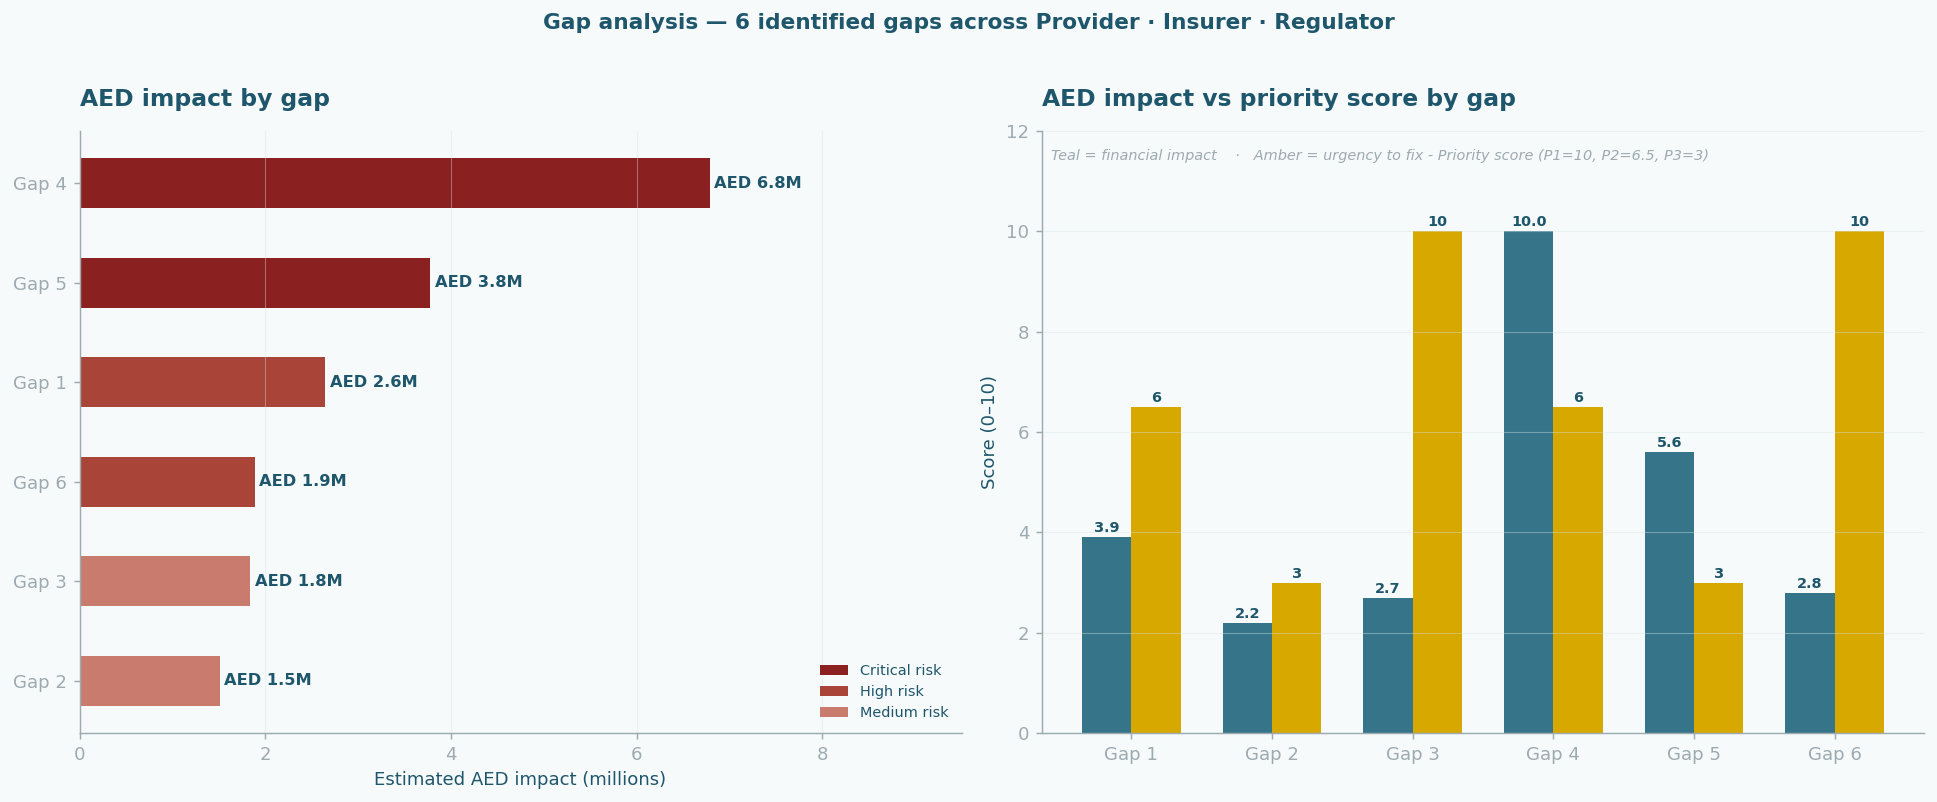


Gap analysis complete ✓
Next: Notebook 3 — To-Be process design


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

from matplotlib.patches import Patch

# ── Chart A: AED impact by gap ────────────────────────────────
gap_plot = gap_summary.sort_values('AED_impact', ascending=True).reset_index(drop=True)
bar_colors = ['#C97B6E', '#C97B6E', '#A94438', '#A94438', '#8B2020', '#8B2020']

bars = axes[0].barh(
    [f"Gap {int(g)}" for g in gap_plot['Gap']],
    gap_plot['AED_impact'] / 1_000_000,
    color=bar_colors, height=0.5, edgecolor='none')

for bar, (_, row) in zip(bars, gap_plot.iterrows()):
    axes[0].text(bar.get_width() + 0.05,
                 bar.get_y() + bar.get_height()/2,
                 f"AED {row['AED_impact']/1_000_000:.1f}M",
                 va='center', fontsize=9, color=NAVY, fontweight='bold')

legend_els = [
    Patch(facecolor='#8B2020', label='Critical risk'),
    Patch(facecolor='#A94438', label='High risk'),
    Patch(facecolor='#C97B6E', label='Medium risk'),
]
axes[0].legend(handles=legend_els, framealpha=0, fontsize=8, loc='lower right')
axes[0].set_xlabel('Estimated AED impact (millions)')
axes[0].set_title('AED impact by gap', loc='left')
axes[0].set_xlim(0, gap_plot['AED_impact'].max() / 1_000_000 * 1.4)
axes[0].grid(axis='x', alpha=0.4)

# ── Chart B: Grouped bars ─────────────────────────────────────
gap_sorted     = gap_summary.sort_values('Gap').reset_index(drop=True)
x              = np.arange(len(gap_sorted))
bar_width      = 0.35
aed_norm       = (gap_sorted['AED_impact'] / gap_sorted['AED_impact'].max() * 10).round(1)
priority_score = gap_sorted['Priority'].map({1: 10, 2: 6.5, 3: 3})

b1 = axes[1].bar(x - bar_width/2, aed_norm,
                 width=bar_width, color=TEAL_DARK,
                 edgecolor='none', label='AED impact (normalised 0–10)')
b2 = axes[1].bar(x + bar_width/2, priority_score,
                 width=bar_width, color='#D7A800',
                 edgecolor='none', label='Priority score (P1=10, P2=6.5, P3=3)')

for bar, val in zip(b1, aed_norm):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.1,
                 f'{val:.1f}', ha='center', fontsize=8,
                 color=NAVY, fontweight='bold')

for bar, val in zip(b2, priority_score):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.1,
                 f'{val:.0f}', ha='center', fontsize=8,
                 color=NAVY, fontweight='bold')

axes[1].set_xticks(x)
axes[1].set_xticklabels([f"Gap {int(g)}" for g in gap_sorted['Gap']])
axes[1].set_ylabel('Score (0–10)')
axes[1].set_title('AED impact vs priority score by gap', loc='left')
axes[1].set_ylim(0, 12)
axes[1].annotate('Teal = financial impact    ·   Amber = urgency to fix - Priority score (P1=10, P2=6.5, P3=3)',
                 xy=(0.01, 0.97), xycoords='axes fraction',
                 fontsize=8, color=GRAY, style='italic', va='top')
axes[1].grid(axis='y', alpha=0.4)

fig.suptitle('Gap analysis — 6 identified gaps across Provider · Insurer · Regulator',
             fontsize=12, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/03_gap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nGap analysis complete ✓")
print("Next: Notebook 3 — To-Be process design")